
XGBoost Performance:
Accuracy: 0.7662
Precision: 0.5513
Recall: 0.6417
F1 Score: 0.5931
ROC AUC: 0.8226

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1552
           1       0.55      0.64      0.59       561

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.71      2113
weighted avg       0.78      0.77      0.77      2113



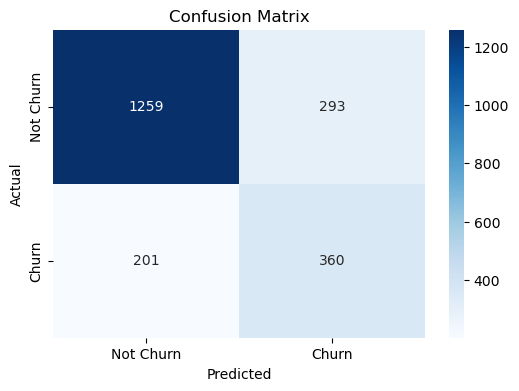

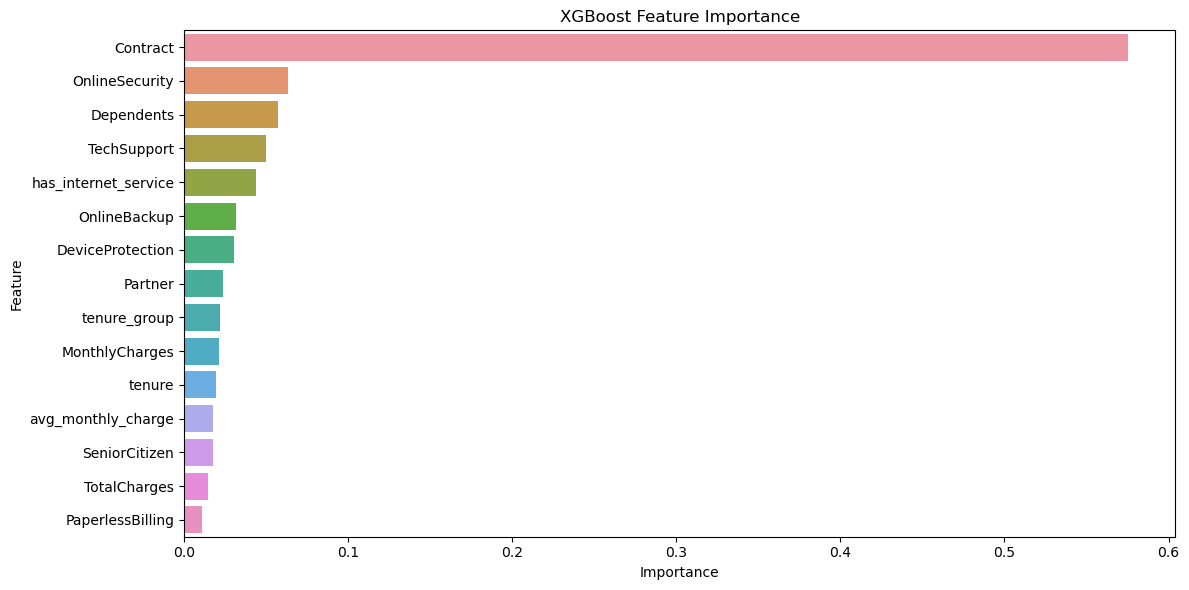


Sample Predictions:
Customer 1: Churn Probability = 0.7015, Predicted = Yes
Customer 2: Churn Probability = 0.0638, Predicted = No
Customer 3: Churn Probability = 0.4945, Predicted = No
Customer 4: Churn Probability = 0.1251, Predicted = No
Customer 5: Churn Probability = 0.8041, Predicted = Yes


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = pd.read_excel("C:/Users/User/Downloads/Churn_prediction_data.xlsx")

# Convert TotalCharges to numeric, fill missing with 0
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(0, inplace=True)

# Feature engineering
def tenure_group(row):
    if row['tenure'] <= 12:
        return "Tenure_0-12"
    elif row['tenure'] <= 24:
        return "Tenure_12-24"
    elif row['tenure'] <= 36:
        return "Tenure_24-36"
    elif row['tenure'] <= 48:
        return "Tenure_36-48"
    elif row['tenure'] <= 60:
        return "Tenure_48-60"
    else:
        return "Tenure_gt_60"

data['tenure_group'] = data.apply(tenure_group, axis=1)
data['avg_monthly_charge'] = data['TotalCharges'] / (data['tenure'] + 0.001)
data['has_internet_service'] = data['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
data['has_phone_service'] = data['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)

services = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies']
data['total_services'] = data[services].apply(lambda x: sum([1 if i == 'Yes' else 0 for i in x]), axis=1)

# Encode categorical variables
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Encode target variable
data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Define features and target
X = data.drop(['Churn'], axis=1)
y = data['Churn']

# Select top 15 features
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = X[selected_features]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale numeric features
scaler = StandardScaler()
num_cols = [col for col in ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'total_services']
            if col in X.columns]
X_train_smote[num_cols] = scaler.fit_transform(X_train_smote[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Train and evaluate XGBoost model
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return model, y_prob

print("\nXGBoost Performance:")
xgb_model = XGBClassifier(random_state=42, learning_rate=0.1, n_estimators=100)
xgb_model, xgb_probs = evaluate_model(xgb_model, X_train_smote, y_train_smote, X_test, y_test)

# Feature importance plot
plt.figure(figsize=(12, 6))
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Save model and scaler
joblib.dump(xgb_model, 'xgb_churn_model.pkl')
joblib.dump(scaler, 'xgb_churn_scaler.pkl')

# Define prediction function
def predict_churn(new_data):
    model = joblib.load('xgb_churn_model.pkl')
    scaler = joblib.load('xgb_churn_scaler.pkl')

    # Reapply feature engineering
    new_data['avg_monthly_charge'] = new_data['TotalCharges'] / (new_data['tenure'] + 0.001)
    new_data['has_internet_service'] = new_data['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
    new_data['has_phone_service'] = new_data['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)
    new_data['total_services'] = new_data[services].apply(lambda x: sum([1 if i == 'Yes' else 0 for i in x]), axis=1)

    for col in cat_cols:
        le = LabelEncoder()
        le.fit(data[col])
        new_data[col] = le.transform(new_data[col])

    new_data = new_data[selected_features]
    new_data[num_cols] = scaler.transform(new_data[num_cols])

    churn_prob = model.predict_proba(new_data)[:, 1]
    churn_pred = (churn_prob >= 0.5).astype(int)

    return churn_prob, churn_pred

# Sample prediction
sample_data = data.iloc[:5].copy()
sample_data['tenure'] = [5, 10, 15, 20, 25]
sample_data['MonthlyCharges'] = [50, 75, 100, 125, 150]

probs, preds = predict_churn(sample_data)

print("\nSample Predictions:")
for i, (p, pr) in enumerate(zip(probs, preds)):
    print(f"Customer {i+1}: Churn Probability = {p:.4f}, Predicted = {'Yes' if pr == 1 else 'No'}")
